
# EDA — Classification des sentiments (movies1000)

Ce notebook réalise une analyse exploratoire simple et utile pour le rapport :

- structure du corpus
- répartition des classes
- longueur des reviews
- comparaison des longueurs selon le sentiment
- distribution des longueurs
- mots fréquents par classe
- exemples de reviews courts et longs

Les graphiques produits peuvent être réutilisés dans le rapport.


In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:

# Si besoin sur Colab, décommente :
!pip install -q pandas matplotlib scikit-learn wordcloud


In [4]:

from pathlib import Path
import re
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import ENGLISH_STOP_WORDS
from wordcloud import WordCloud


## 1. Configuration

In [5]:

DATA_DIR = Path("/content/drive/MyDrive/projet tal/movies1000/movies1000")
OUTPUT_DIR = Path("/content/drive/MyDrive/projet tal/eda_sentiment_outputs")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

print("DATA_DIR existe :", DATA_DIR.exists())
print("OUTPUT_DIR :", OUTPUT_DIR)


DATA_DIR existe : True
OUTPUT_DIR : /content/drive/MyDrive/projet tal/eda_sentiment_outputs


## 2. Chargement des données

In [6]:

def load_movies_from_folder(data_dir: Path) -> pd.DataFrame:
    rows = []

    for label_folder, label in [("pos", "P"), ("neg", "N")]:
        folder = data_dir / label_folder
        if not folder.exists():
            continue

        for file_path in folder.glob("*.txt"):
            text = file_path.read_text(encoding="utf-8", errors="ignore")
            rows.append({
                "doc_id": file_path.name,
                "label": label,
                "text": text,
            })

    if not rows:
        raise ValueError("Aucun fichier trouvé. Vérifie DATA_DIR.")

    return pd.DataFrame(rows).sort_values("doc_id").reset_index(drop=True)

df = load_movies_from_folder(DATA_DIR)
print("Taille du corpus :", df.shape)
display(df.head())


Taille du corpus : (2000, 3)


,doc_id,label,text
0,cv000_29416.txt,N,"plot : two teen couples go to a church party ,..."
1,cv000_29590.txt,P,films adapted from comic books have had plenty...
2,cv001_18431.txt,P,every now and then a movie comes along from a ...
3,cv001_19502.txt,N,the happy bastard's quick movie review \ndamn ...
4,cv002_15918.txt,P,you've got mail works alot better than it dese...


## 3. Vérification rapide du corpus

In [7]:

print("Colonnes :", df.columns.tolist())
print("Labels uniques :", sorted(df["label"].unique()))
print("Nombre de documents par classe :")
display(df["label"].value_counts().rename_axis("label").reset_index(name="count"))


Colonnes : ['doc_id', 'label', 'text']
Labels uniques : ['N', 'P']
Nombre de documents par classe :


,label,count
0,N,1000
1,P,1000


## 4. Features simples : longueur des reviews

In [8]:

def count_words(text: str) -> int:
    return len(text.split())

def simple_tokenize(text: str):
    return re.findall(r"[A-Za-z']+", text.lower())

df["n_chars"] = df["text"].str.len()
df["n_words"] = df["text"].apply(count_words)
df["n_lines"] = df["text"].str.count(r"\n") + 1
df["tokens_simple"] = df["text"].apply(simple_tokenize)
df["n_tokens_simple"] = df["tokens_simple"].apply(len)

summary_df = pd.DataFrame({
    "stat": ["n_docs", "avg_chars", "median_chars", "avg_words", "median_words", "avg_lines", "median_lines"],
    "value": [
        len(df),
        df["n_chars"].mean(),
        df["n_chars"].median(),
        df["n_words"].mean(),
        df["n_words"].median(),
        df["n_lines"].mean(),
        df["n_lines"].median(),
    ]
})
display(summary_df)


,stat,value
0,n_docs,2000.0000
1,avg_chars,3893.0020
2,median_chars,3622.5000
3,avg_words,746.3405
4,median_words,696.5000
5,avg_lines,33.3600
6,median_lines,31.0000


## 5. Répartition des classes

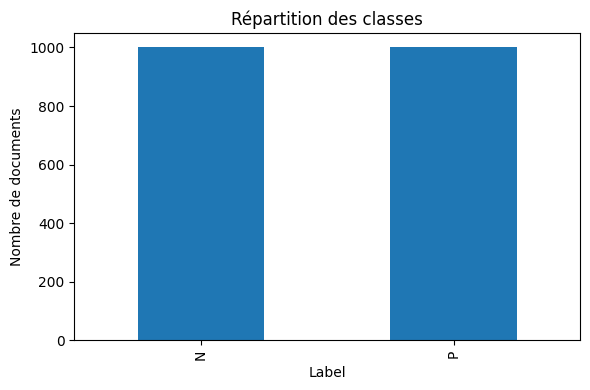

,label,count
0,N,1000
1,P,1000


In [9]:

class_counts = df["label"].value_counts().sort_index()

plt.figure(figsize=(6, 4))
class_counts.plot(kind="bar")
plt.title("Répartition des classes")
plt.xlabel("Label")
plt.ylabel("Nombre de documents")
plt.tight_layout()
plt.show()

class_counts_df = class_counts.rename_axis("label").reset_index(name="count")
display(class_counts_df)


## 6. Statistiques de longueur par classe

In [10]:

length_by_class = df.groupby("label")[["n_chars", "n_words", "n_lines", "n_tokens_simple"]].agg(["mean", "median", "min", "max"])
display(length_by_class)


n_chars                      n_words                   n_lines         \
           mean  median  min    max     mean median  min   max    mean median   
label                                                                           
N      3661.721  3455.5   91  11408  705.630  668.5   17  2181  32.783   31.0   
P      4124.283  3840.5  727  14957  787.051  731.5  130  2678  33.937   32.0   

               n_tokens_simple                    
      min  max            mean median  min   max  
label                                             
N       2  113         615.132  580.0   16  1851  
P       6  113         688.821  641.5  115  2390

## 7. Histogramme du nombre de mots

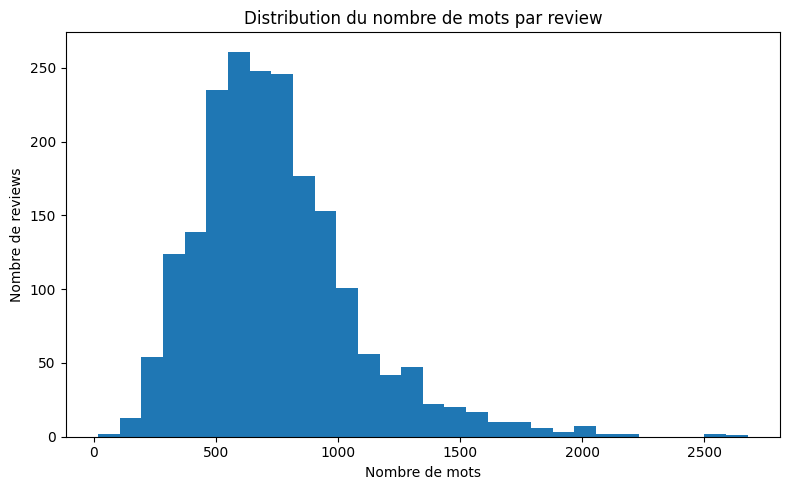

In [11]:

plt.figure(figsize=(8, 5))
plt.hist(df["n_words"], bins=30)
plt.title("Distribution du nombre de mots par review")
plt.xlabel("Nombre de mots")
plt.ylabel("Nombre de reviews")
plt.tight_layout()
plt.show()


## 8. Histogrammes par classe

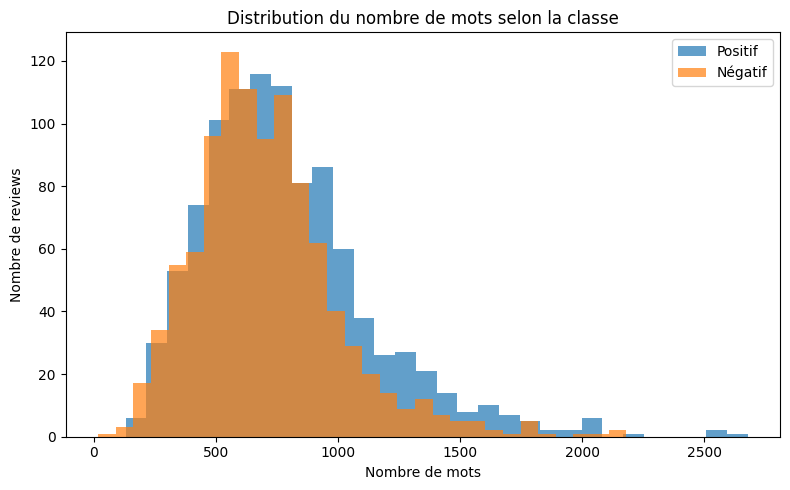

In [12]:

plt.figure(figsize=(8, 5))
plt.hist(df[df["label"] == "P"]["n_words"], bins=30, alpha=0.7, label="Positif")
plt.hist(df[df["label"] == "N"]["n_words"], bins=30, alpha=0.7, label="Négatif")
plt.title("Distribution du nombre de mots selon la classe")
plt.xlabel("Nombre de mots")
plt.ylabel("Nombre de reviews")
plt.legend()
plt.tight_layout()
plt.show()


## 9. Boxplot des longueurs

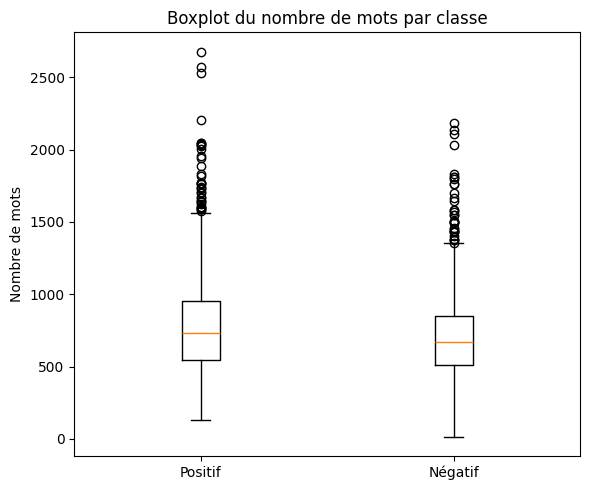

In [13]:

data_box = [
    df[df["label"] == "P"]["n_words"].values,
    df[df["label"] == "N"]["n_words"].values,
]

plt.figure(figsize=(6, 5))
plt.boxplot(data_box, tick_labels=["Positif", "Négatif"])
plt.title("Boxplot du nombre de mots par classe")
plt.ylabel("Nombre de mots")
plt.tight_layout()
plt.show()


## 10. Quantiles de longueur

In [14]:

quantiles = df["n_words"].quantile([0.1, 0.25, 0.5, 0.75, 0.9, 0.95, 0.99]).rename("n_words_quantile")
display(quantiles.to_frame())


,n_words_quantile
0.10,378.00
0.25,526.75
0.50,696.50
0.75,904.00
0.90,1153.10
0.95,1355.05
0.99,1812.03


## 11. Reviews les plus courtes et les plus longues

In [15]:

short_reviews = df.nsmallest(5, "n_words")[["doc_id", "label", "n_words", "text"]]
long_reviews = df.nlargest(5, "n_words")[["doc_id", "label", "n_words", "text"]]

print("Reviews les plus courtes :")
display(short_reviews)

print("Reviews les plus longues :")
display(long_reviews)


Reviews les plus courtes :


,doc_id,label,n_words,text
1013,cv506_17521.txt,N,17,this film is extraordinarily horrendous and i'...
1559,cv779_18989.txt,N,94,"9 : its pathetic attempt at "" improving "" on a..."
1715,cv857_17527.txt,N,117,"claire danes , giovanni ribisi , and omar epps..."
560,cv280_8267.txt,P,130,this three hour movie opens up with a view of ...
871,cv435_24355.txt,N,134,a couple of criminals ( mario van peebles and ...


Reviews les plus longues :


,doc_id,label,n_words,text
1105,cv552_10016.txt,P,2678,note : some may consider portions of the follo...
1194,cv597_26360.txt,P,2570,""" say , any of you know how to madison ? "" \n..."
1530,cv765_19037.txt,P,2529,i remember seeing the trailer of the black cau...
1277,cv638_2953.txt,P,2203,natural born killers is really a very simple s...
1465,cv732_13092.txt,N,2181,i think that saying that the x-files is one of...


## 12. Mots fréquents par classe

In [16]:

stopwords = set(ENGLISH_STOP_WORDS)

def get_top_words(texts, top_k=30):
    counter = Counter()
    for text in texts:
        tokens = re.findall(r"[A-Za-z']+", text.lower())
        tokens = [t for t in tokens if t not in stopwords and len(t) > 2]
        counter.update(tokens)
    return pd.DataFrame(counter.most_common(top_k), columns=["word", "count"])

top_pos = get_top_words(df[df["label"] == "P"]["text"], top_k=20)
top_neg = get_top_words(df[df["label"] == "N"]["text"], top_k=20)

print("Top mots - Positif")
display(top_pos)

print("Top mots - Négatif")
display(top_neg)


Top mots - Positif


,word,count
0,film,4910
1,movie,2421
2,it's,1892
3,like,1803
4,just,1342
5,good,1246
6,time,1242
7,story,1223
8,life,1048
9,character,1023


Top mots - Négatif


,word,count
0,film,4027
1,movie,3121
2,like,1888
3,it's,1827
4,just,1563
5,time,1167
6,good,1161
7,bad,1034
8,story,914
9,plot,912


## 13. Barplots des mots fréquents

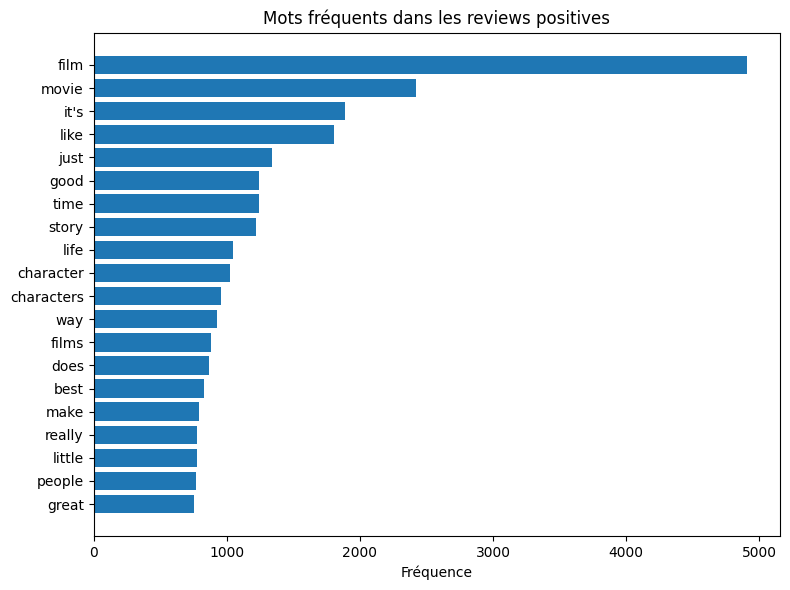

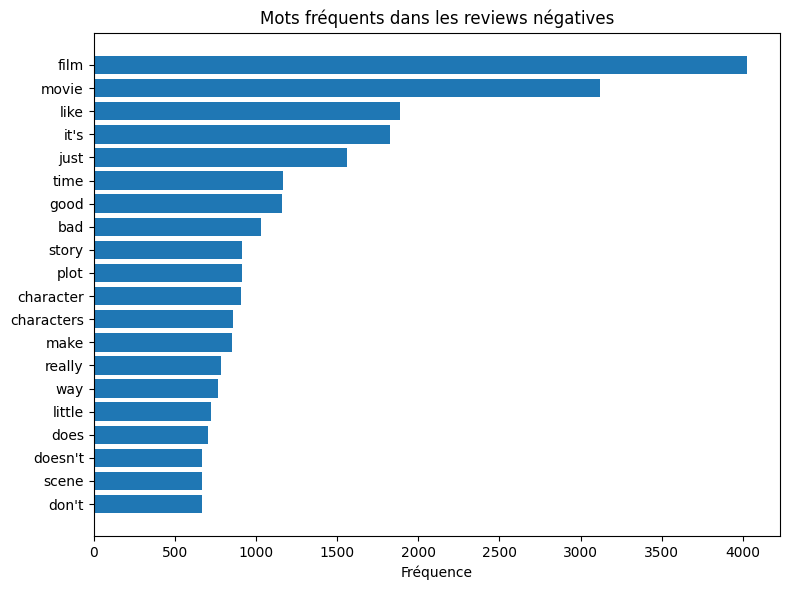

In [17]:

plt.figure(figsize=(8, 6))
plt.barh(top_pos["word"][::-1], top_pos["count"][::-1])
plt.title("Mots fréquents dans les reviews positives")
plt.xlabel("Fréquence")
plt.tight_layout()
plt.show()

plt.figure(figsize=(8, 6))
plt.barh(top_neg["word"][::-1], top_neg["count"][::-1])
plt.title("Mots fréquents dans les reviews négatives")
plt.xlabel("Fréquence")
plt.tight_layout()
plt.show()


## 14. Nuages de mots

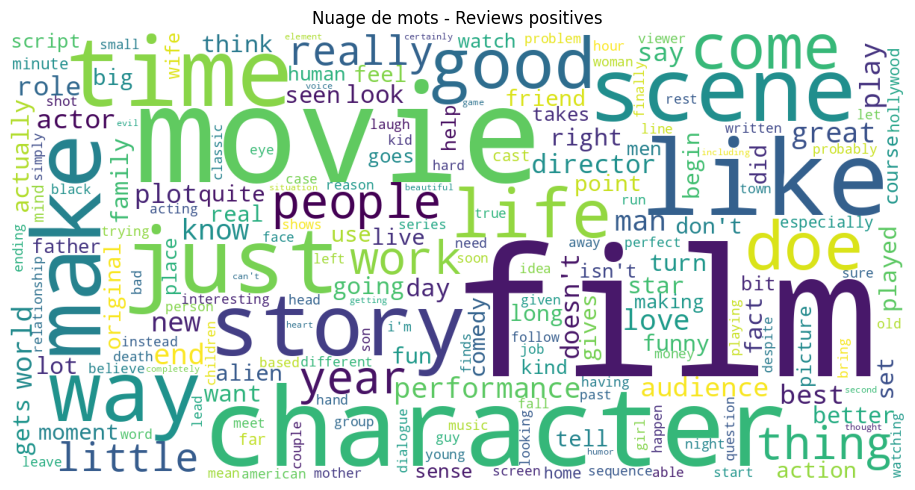

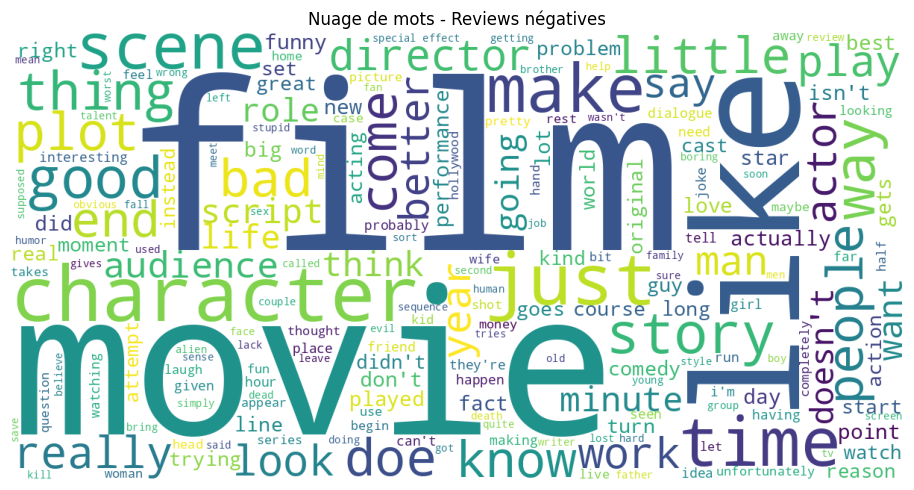

In [18]:

pos_text = " ".join(df[df["label"] == "P"]["text"].tolist())
neg_text = " ".join(df[df["label"] == "N"]["text"].tolist())

wc_pos = WordCloud(width=1200, height=600, background_color="white", stopwords=stopwords).generate(pos_text)
wc_neg = WordCloud(width=1200, height=600, background_color="white", stopwords=stopwords).generate(neg_text)

plt.figure(figsize=(12, 5))
plt.imshow(wc_pos)
plt.axis("off")
plt.title("Nuage de mots - Reviews positives")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 5))
plt.imshow(wc_neg)
plt.axis("off")
plt.title("Nuage de mots - Reviews négatives")
plt.tight_layout()
plt.show()


## 15. Tableau récapitulatif pour le rapport

In [19]:

report_table = pd.DataFrame([
    {"measure": "Nombre total de documents", "value": len(df)},
    {"measure": "Nombre de documents positifs", "value": int((df['label'] == 'P').sum())},
    {"measure": "Nombre de documents négatifs", "value": int((df['label'] == 'N').sum())},
    {"measure": "Longueur moyenne (mots)", "value": round(df["n_words"].mean(), 2)},
    {"measure": "Longueur médiane (mots)", "value": round(df["n_words"].median(), 2)},
    {"measure": "Longueur max (mots)", "value": int(df["n_words"].max())},
    {"measure": "Longueur min (mots)", "value": int(df["n_words"].min())},
])

display(report_table)


,measure,value
0,Nombre total de documents,2000.00
1,Nombre de documents positifs,1000.00
2,Nombre de documents négatifs,1000.00
3,Longueur moyenne (mots),746.34
4,Longueur médiane (mots),696.50
5,Longueur max (mots),2678.00
6,Longueur min (mots),17.00


## 16. Export optionnel des tableaux

In [20]:

report_table.to_csv(OUTPUT_DIR / "report_table_summary.csv", index=False)
top_pos.to_csv(OUTPUT_DIR / "top_words_positive.csv", index=False)
top_neg.to_csv(OUTPUT_DIR / "top_words_negative.csv", index=False)
class_counts_df.to_csv(OUTPUT_DIR / "class_counts.csv", index=False)

print("Tableaux exportés dans :", OUTPUT_DIR)


Tableaux exportés dans : /content/drive/MyDrive/projet tal/eda_sentiment_outputs


## 17. Commentaire final

In [21]:

print("Commentaires possibles pour le rapport :")
print("- Le corpus est équilibré entre les classes positives et négatives.")
print("- Les reviews présentent une longueur variable, avec certaines critiques très longues.")
print("- Cette variabilité de longueur peut compliquer l'utilisation de modèles Transformers limités en nombre de tokens.")
print("- L'analyse lexicale montre des tendances distinctes entre les reviews positives et négatives.")


Commentaires possibles pour le rapport :
- Le corpus est équilibré entre les classes positives et négatives.
- Les reviews présentent une longueur variable, avec certaines critiques très longues.
- Cette variabilité de longueur peut compliquer l'utilisation de modèles Transformers limités en nombre de tokens.
- L'analyse lexicale montre des tendances distinctes entre les reviews positives et négatives.
